

>** Introduction**





Customer churn is a critical issue in the telecom industry, as retaining customers is more cost-effective than acquiring new ones. This project analyzes a telecom customer churn dataset to identify key factors influencing churn. Using exploratory data analysis and visualizations, customer behavior, service usage, pricing, and demographics are examined. A machine learning model is also developed to understand churn prediction and support data-driven retention strategies.



In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load the CSV files
churn_df = pd.read_csv('/content/drive/MyDrive/python .csv file/telecom_customer_churn.csv')
data_dict_df = pd.read_csv('/content/drive/MyDrive/python .csv file/telecom_data_dictionary.csv', encoding='latin1')
zipcode_df = pd.read_csv('/content/drive/MyDrive/python .csv file/telecom_zipcode_population.csv', encoding='latin1')


In [4]:
# Preview the data
print(churn_df.head())

  Customer ID  Gender  Age Married  Number of Dependents          City  \
0  0002-ORFBO  Female   37     Yes                     0  Frazier Park   
1  0003-MKNFE    Male   46      No                     0      Glendale   
2  0004-TLHLJ    Male   50      No                     0    Costa Mesa   
3  0011-IGKFF    Male   78     Yes                     0      Martinez   
4  0013-EXCHZ  Female   75     Yes                     0     Camarillo   

   Zip Code   Latitude   Longitude  Number of Referrals  ...   Payment Method  \
0     93225  34.827662 -118.999073                    2  ...      Credit Card   
1     91206  34.162515 -118.203869                    0  ...      Credit Card   
2     92627  33.645672 -117.922613                    0  ...  Bank Withdrawal   
3     94553  38.014457 -122.115432                    1  ...  Bank Withdrawal   
4     93010  34.227846 -119.079903                    3  ...      Credit Card   

  Monthly Charge Total Charges  Total Refunds Total Extra Data Charg

In [5]:
print(data_dict_df.head())

            Table                 Field  \
0  Customer Churn            CustomerID   
1  Customer Churn                Gender   
2  Customer Churn                   Age   
3  Customer Churn               Married   
4  Customer Churn  Number of Dependents   

                                         Description  
0          A unique ID that identifies each customer  
1                The customers gender: Male, Female  
2  The customers current age, in years, at the t...  
3      Indicates if the customer is married: Yes, No  
4  Indicates the number of dependents that live w...  


In [6]:
print(zipcode_df.head())


   Zip Code  Population
0     90001       54492
1     90002       44586
2     90003       58198
3     90004       67852
4     90005       43019


In [7]:
print(churn_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

In [8]:
print(churn_df.describe())

               Age  Number of Dependents      Zip Code     Latitude  \
count  7043.000000           7043.000000   7043.000000  7043.000000   
mean     46.509726              0.468692  93486.070567    36.197455   
std      16.750352              0.962802   1856.767505     2.468929   
min      19.000000              0.000000  90001.000000    32.555828   
25%      32.000000              0.000000  92101.000000    33.990646   
50%      46.000000              0.000000  93518.000000    36.205465   
75%      60.000000              0.000000  95329.000000    38.161321   
max      80.000000              9.000000  96150.000000    41.962127   

         Longitude  Number of Referrals  Tenure in Months  \
count  7043.000000          7043.000000       7043.000000   
mean   -119.756684             1.951867         32.386767   
std       2.154425             3.001199         24.542061   
min    -124.301372             0.000000          1.000000   
25%    -121.788090             0.000000          9.0000

In [9]:
# Check for missing values
print(churn_df.isnull().sum())

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

In [10]:
print(churn_df.isnull().sum().sum())

30849


In [11]:
churn_df.fillna(method='ffill', inplace=True)

/tmp/ipython-input-4129277805.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  churn_df.fillna(method='ffill', inplace=True)


In [12]:
print(churn_df.isnull().sum().sum())

6


In [13]:
print(churn_df.isnull().sum())

Customer ID                          0
Gender                               0
Age                                  0
Married                              0
Number of Dependents                 0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Number of Referrals                  0
Tenure in Months                     0
Offer                                2
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited Data           

In [14]:
churn_df['Offer'].fillna('No Offer', inplace=True)
churn_df['Churn Category'].fillna('Unknown', inplace=True)
churn_df['Churn Reason'].fillna('Unknown Reason', inplace=True)

/tmp/ipython-input-493860895.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  churn_df['Offer'].fillna('No Offer', inplace=True)
/tmp/ipython-input-493860895.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [15]:
print(churn_df.isnull().sum().sum())

0


In [16]:
print(zipcode_df.isnull().sum().sum())



0


In [17]:
# Display duplicate rows
print(zipcode_df[zipcode_df.duplicated()])



Empty DataFrame
Columns: [Zip Code, Population]
Index: []


In [18]:
churn_df.duplicated().sum()

np.int64(0)

In [19]:
# Check for duplicate Customer IDs
churn_df['Customer ID'].duplicated().sum()

np.int64(0)

In [20]:
zipcode_df.fillna(method='ffill', inplace=True)

/tmp/ipython-input-938143734.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  zipcode_df.fillna(method='ffill', inplace=True)


In [21]:
churn_df[churn_df.duplicated()]

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason


In [22]:
print(churn_df.head())

  Customer ID  Gender  Age Married  Number of Dependents          City  \
0  0002-ORFBO  Female   37     Yes                     0  Frazier Park   
1  0003-MKNFE    Male   46      No                     0      Glendale   
2  0004-TLHLJ    Male   50      No                     0    Costa Mesa   
3  0011-IGKFF    Male   78     Yes                     0      Martinez   
4  0013-EXCHZ  Female   75     Yes                     0     Camarillo   

   Zip Code   Latitude   Longitude  Number of Referrals  ...   Payment Method  \
0     93225  34.827662 -118.999073                    2  ...      Credit Card   
1     91206  34.162515 -118.203869                    0  ...      Credit Card   
2     92627  33.645672 -117.922613                    0  ...  Bank Withdrawal   
3     94553  38.014457 -122.115432                    1  ...  Bank Withdrawal   
4     93010  34.227846 -119.079903                    3  ...      Credit Card   

  Monthly Charge Total Charges  Total Refunds Total Extra Data Charg

#Merge the datasets using Zip Code:

In [23]:
merged_df = pd.merge(churn_df, zipcode_df, on='Zip Code', how='left')
 # 'left' join to keep all customers


In [24]:
merged_df.head()   #Inspect the merged data


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Population
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,65.6,593.30,0.00,0,381.51,974.81,Stayed,Unknown,Unknown Reason,4498
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,-4.0,542.40,38.33,10,96.21,610.28,Stayed,Unknown,Unknown Reason,31297
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,62069
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,46677
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,42853


In [25]:
# Check for missing values
merged_df.isnull().sum().sum()

np.int64(0)

In [26]:
merged_df.duplicated().sum()


np.int64(0)

# Exploratory Data Analysis (EDA)




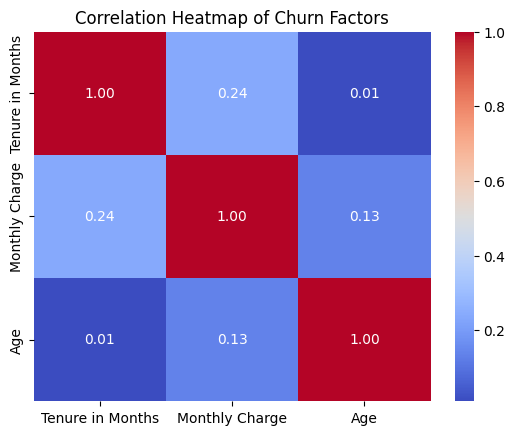

In [27]:
# Main factors influencing churn (Correlation Analysis)
correlation = churn_df[['Tenure in Months', 'Monthly Charge', 'Age']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Churn Factors')
plt.show()


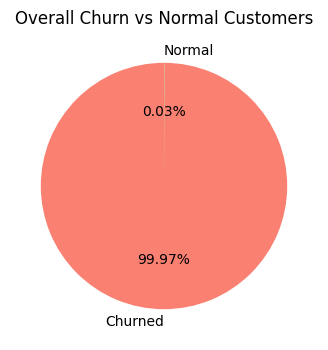

In [28]:
#  Overall Churn vs Normal Customers
churn_simple = churn_df['Churn Category'].apply(lambda x: 'Churned' if x != 'Unknown' else 'Normal').value_counts()
plt.figure(figsize=(6,4))
plt.pie(churn_simple, labels=churn_simple.index, autopct='%1.2f%%', startangle=90, colors=['salmon','lightgreen'])
plt.title("Overall Churn vs Normal Customers")
plt.show()

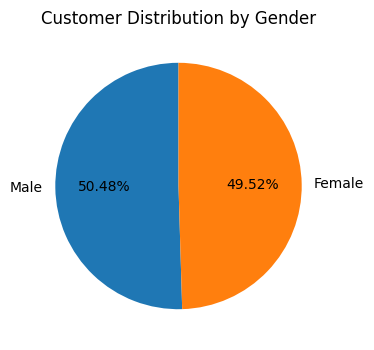

In [29]:
#  Customer Gender Distribution
gender_counts = churn_df['Gender'].value_counts()
plt.figure(figsize=(6,4))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.2f%%', startangle=90)
plt.title("Customer Distribution by Gender")
plt.show()

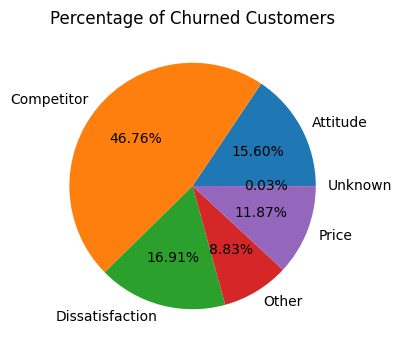

In [30]:
# churn distrebution by category
gb = churn_df.groupby("Churn Category").agg({'Churn Category': 'count'})
plt.figure(figsize=(6, 4))
plt.pie(gb['Churn Category'], labels=gb.index, autopct="%1.2f%%")
plt.title("Percentage of Churned Customers")
plt.show()

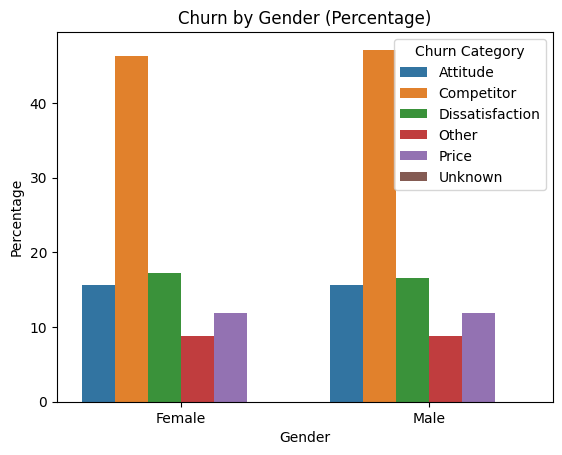

In [31]:
# Churn Analysis by Gender and Churn Category
churn_percentage = churn_df.groupby(['Gender', 'Churn Category']).size().reset_index(name='Count')
churn_percentage['Percentage'] = churn_percentage['Count'] / churn_percentage.groupby('Gender')['Count'].transform('sum') * 100

# Plot
sns.barplot(x='Gender', y='Percentage', hue='Churn Category', data=churn_percentage)
plt.title('Churn by Gender (Percentage)')
plt.show()

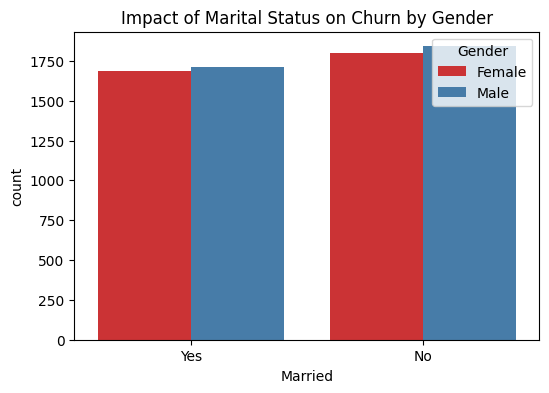

In [32]:
demographics = churn_df[['Married', 'Number of Dependents', 'Churn Category', 'Gender', 'Age']]

# Plotting marital status on churn by gender and age
plt.figure(figsize=(6, 4))
sns.countplot(x='Married', hue='Gender', data=demographics, palette='Set1')
plt.title('Impact of Marital Status on Churn by Gender')
plt.show()

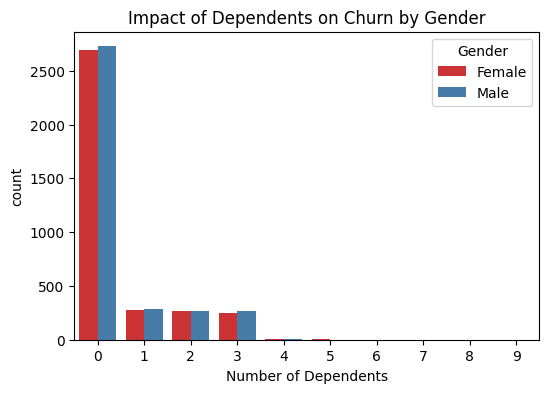

In [33]:
# Plotting dependents on churn by gender and age
plt.figure(figsize=(6, 4))
sns.countplot(x='Number of Dependents', hue='Gender', data=demographics, palette='Set1')
plt.title('Impact of Dependents on Churn by Gender')
plt.show()

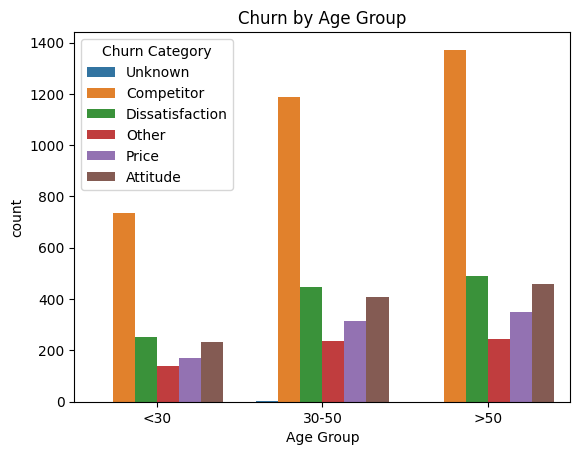

In [34]:
# Churn by Age Groups
bins = [0, 30, 50, 100]
labels = ['<30','30-50','>50']
churn_df['Age Group'] = pd.cut(churn_df['Age'], bins=bins, labels=labels)
sns.countplot(x='Age Group', hue='Churn Category', data=churn_df)
plt.title("Churn by Age Group")
plt.show()

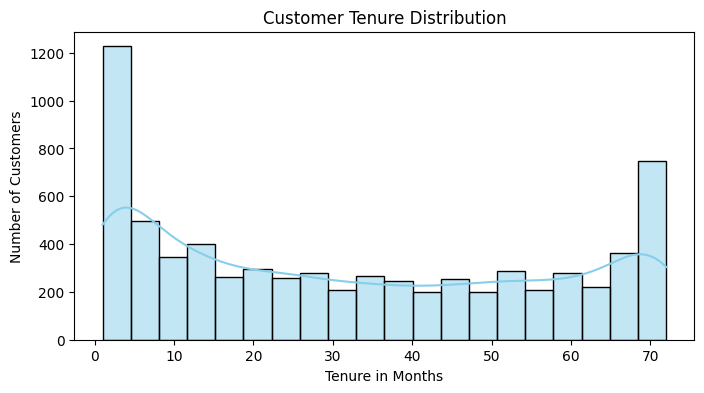

In [35]:
# Customer Tenure Analysis
plt.figure(figsize=(8,4))
sns.histplot(churn_df['Tenure in Months'], bins=20, kde=True, color='skyblue')
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure in Months")
plt.ylabel("Number of Customers")
plt.show()

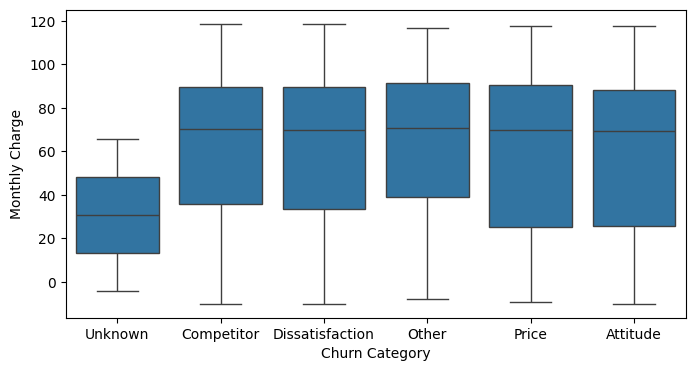

In [36]:
# Monthly Charge analysis:
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn Category', y='Monthly Charge', data=churn_df)  # darker blue
plt.ylabel("Monthly Charge")
plt.show()


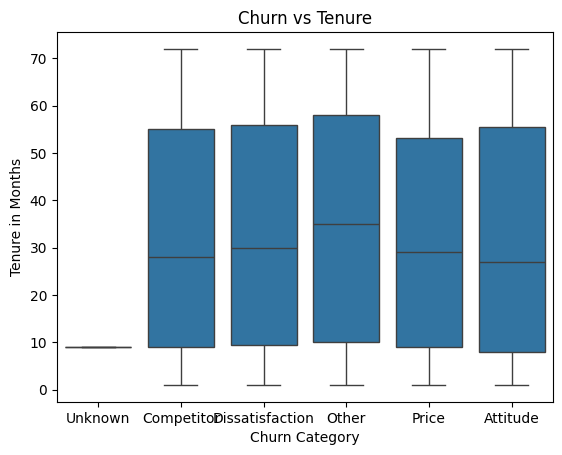

In [37]:
# Tenure vs Churn (Correlation between Tenure and Churn Category)
sns.boxplot(x='Churn Category', y='Tenure in Months', data=churn_df)
plt.title('Churn vs Tenure')
plt.show()

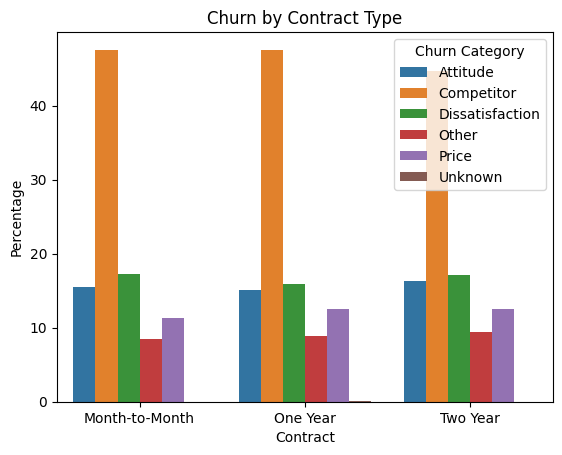

In [38]:
# Impact of Contract Type on Churn
contract_churn_percentage = churn_df.groupby(['Contract', 'Churn Category']).size().reset_index(name='Count')
contract_churn_percentage['Percentage'] = contract_churn_percentage['Count'] / contract_churn_percentage.groupby('Contract')['Count'].transform('sum') * 100

# Plot
sns.barplot(x='Contract', y='Percentage', hue='Churn Category', data=contract_churn_percentage)
plt.title('Churn by Contract Type')
plt.show()


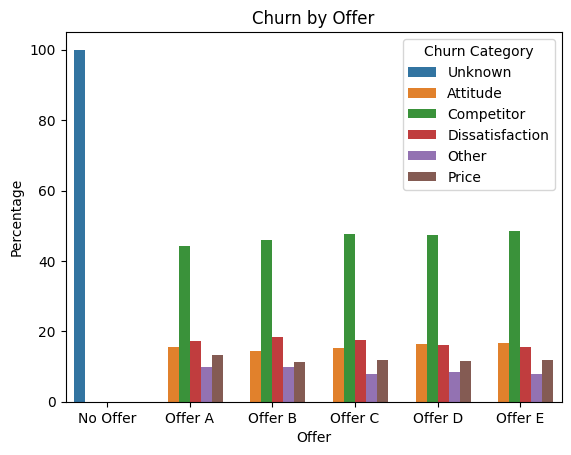

In [39]:
# Churn by Offers
offer_churn = churn_df.groupby(['Offer','Churn Category']).size().reset_index(name='Count')
offer_churn['Percentage'] = offer_churn['Count'] / offer_churn.groupby('Offer')['Count'].transform('sum') * 100
sns.barplot(x='Offer', y='Percentage', hue='Churn Category', data=offer_churn)
plt.title("Churn by Offer")
plt.show()

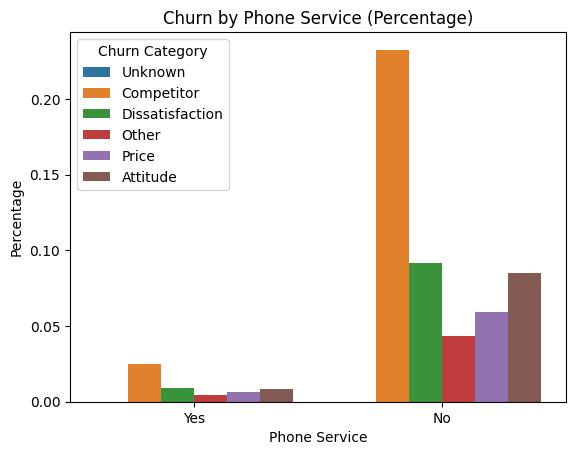

In [40]:
# Calculate count and percentage for each 'Phone Service' and 'Churn Category'
churn_df['Count'] = churn_df.groupby(['Phone Service', 'Churn Category'])['Churn Category'].transform('size')
churn_df['Percentage'] = churn_df['Count'] / churn_df.groupby('Phone Service')['Count'].transform('sum') * 100

# Create a barplot for churn by Phone Service with percentage
sns.barplot(x='Phone Service', y='Percentage', hue='Churn Category', data=churn_df)
plt.title('Churn by Phone Service (Percentage)')
plt.show()


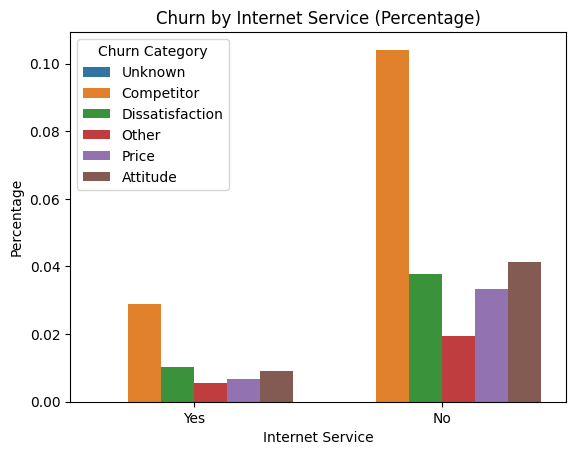

In [41]:
# Calculate count and percentage for each 'Internet Service' and 'Churn Category'
churn_df['Count'] = churn_df.groupby(['Internet Service', 'Churn Category'])['Churn Category'].transform('size')
churn_df['Percentage'] = churn_df['Count'] / churn_df.groupby('Internet Service')['Count'].transform('sum') * 100

# Create a barplot for churn by Internet Service with percentage
sns.barplot(x='Internet Service', y='Percentage', hue='Churn Category', data=churn_df)
plt.title('Churn by Internet Service (Percentage)')
plt.show()


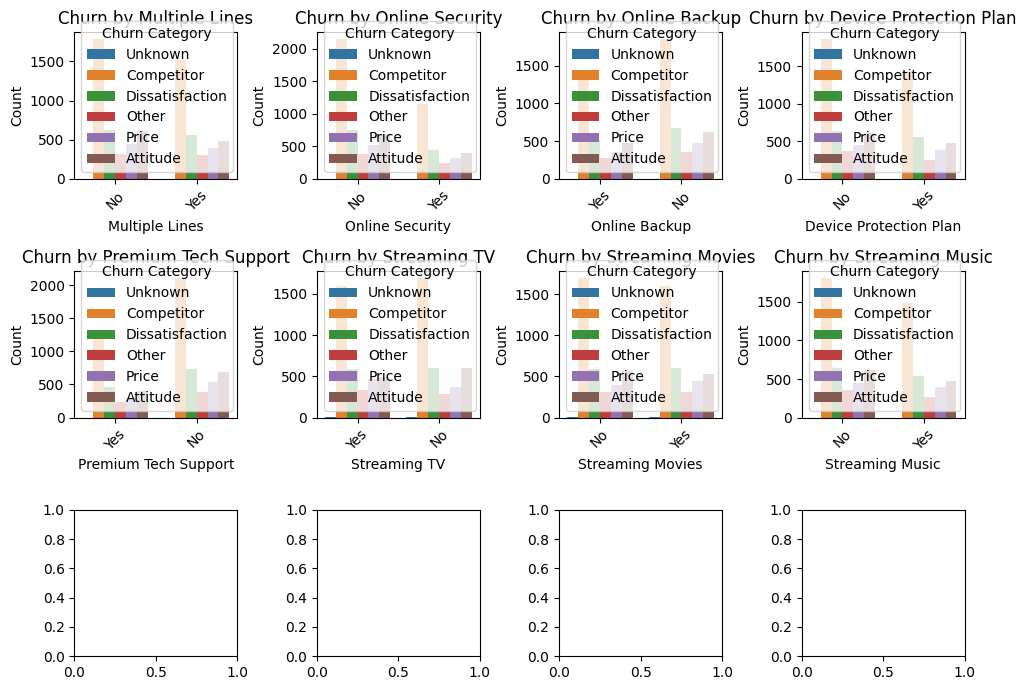

In [42]:
# Service features for churn comparison across customer categories

columns = [
     'Multiple Lines','Online Security',
    'Online Backup', 'Device Protection Plan', 'Premium Tech Support',
    'Streaming TV', 'Streaming Movies', 'Streaming Music'
]

# Set up the subplot grid (e.g., 3 rows, 4 columns)
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(10, 7))

# Flatten the axes array to iterate over
axes = axes.flatten()

# Loop through each feature column and plot a countplot on its respective axis
for i, column in enumerate(columns):
    sns.countplot(x=column, hue='Churn Category', data=churn_df, ax=axes[i])
    axes[i].set_title(f'Churn by {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

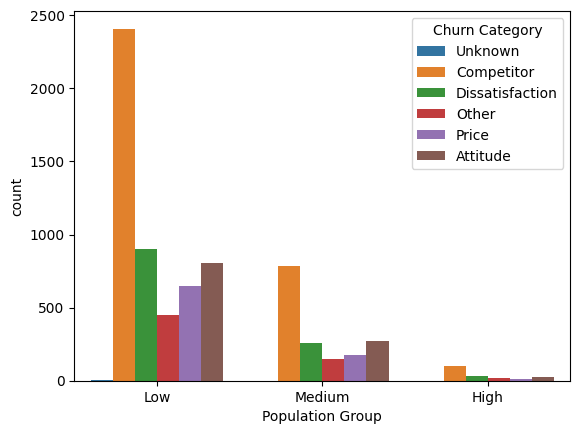

In [43]:
# Merge population data from zipcode_df
merged_df = pd.merge(churn_df, zipcode_df[['Zip Code','Population']], on='Zip Code', how='left')

# Fill missing population values (without inplace)
merged_df['Population'] = merged_df['Population'].fillna(merged_df['Population'].median())

# Create 3 simple population groups
merged_df['Population Group'] = pd.cut(merged_df['Population'], bins=3, labels=['Low','Medium','High'])

# Plot churn by population group (no title)
sns.countplot(x='Population Group', hue='Churn Category', data=merged_df)
plt.show()



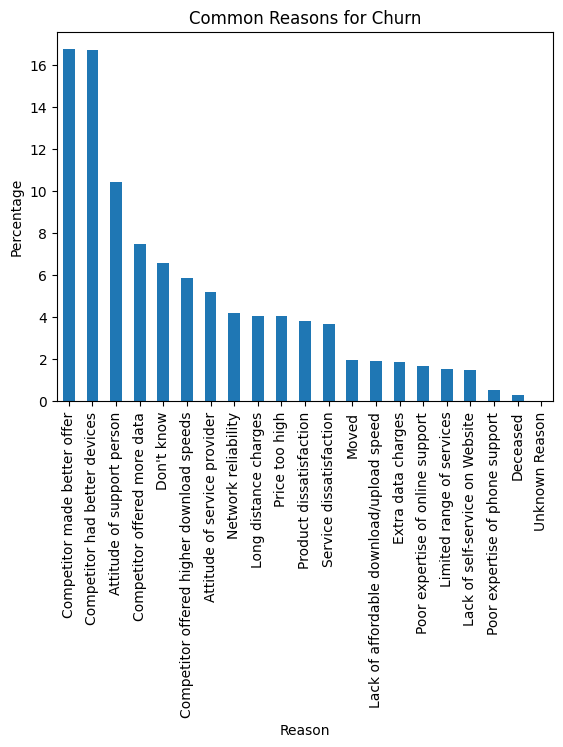

In [44]:
# Churn reasons analysis
churn_reasons = churn_df['Churn Reason'].value_counts(normalize=True) * 100
churn_reasons.plot(kind='bar')
plt.title('Common Reasons for Churn')
plt.xlabel('Reason')
plt.ylabel('Percentage')
plt.show()




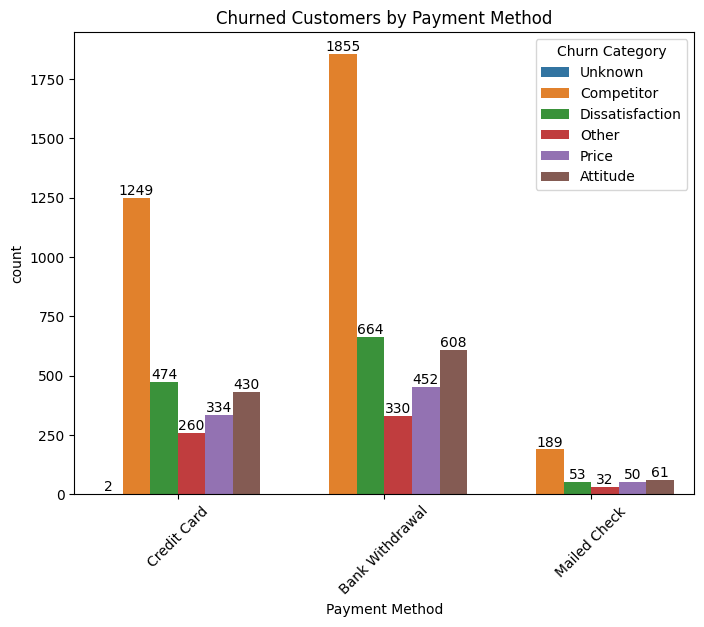

In [45]:
# Churned Customers by Payment Method
plt.figure(figsize=(8, 6))
ax = sns.countplot(x="Payment Method", data=churn_df, hue="Churn Category")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Churned Customers by Payment Method")
plt.xticks(rotation=45)
plt.show()

ML modeling


Accuracy: 1.0

Confusion Matrix:
 [[1409]]

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00      1409

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/tmp/ipython-input-2718986191.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


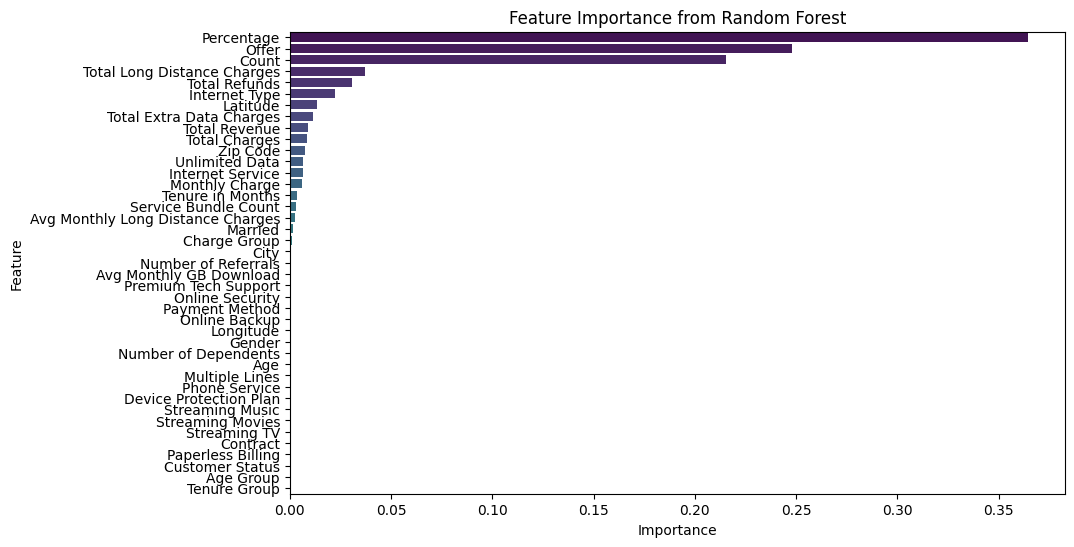

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Prepare target
churn_df['Churn'] = churn_df['Churn Category'].apply(lambda x: 1 if x != 'Unknown' else 0)

# 2️⃣ Drop unnecessary columns if exist
drop_cols = ['Customer ID', 'Churn Category', 'Churn Reason']
existing_drop_cols = [col for col in drop_cols if col in churn_df.columns]

X = churn_df.drop(columns=existing_drop_cols + ['Churn'])
y = churn_df['Churn']

# 3️⃣ Convert known binned columns to numeric
bin_mappings = {
    'Age Group': {'<30':0, '30-50':1, '>50':2},
    'Tenure Group': {'0-12':0, '13-24':1, '25-48':2, '49-60':3, '61-72':4},
    'Charge Group': {'Low':0, 'Medium':1, 'High':2}
}

for col, mapping in bin_mappings.items():
    if col in X.columns:
        X[col] = X[col].map(mapping)

# 4️⃣ Encode remaining categorical columns
categorical_cols = X.select_dtypes(include='object').columns
for col in categorical_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

# 5️⃣ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6️⃣ Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 7️⃣ Predictions and evaluation
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8️⃣ Feature importance plot
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


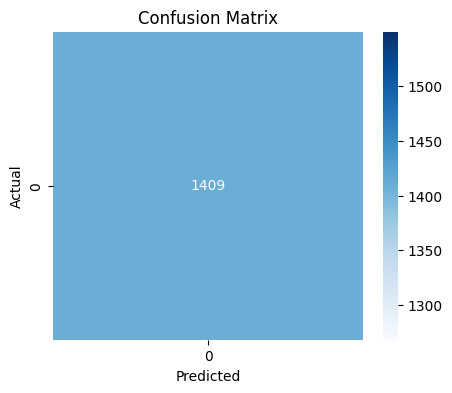

In [ ]:
# Confusion Matrix Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

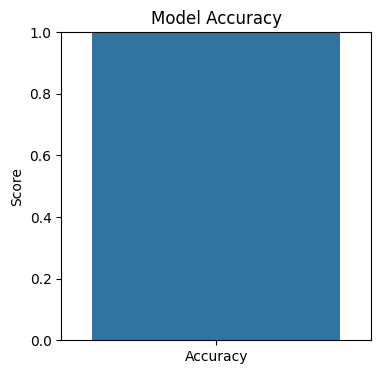

In [ ]:
# Accuracy Plot
plt.figure(figsize=(4,4))
sns.barplot(x=['Accuracy'], y=[acc])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model Accuracy")
plt.show()



**Conclusion**

The analysis shows that churn is mainly influenced by contract type, monthly charges, tenure, and service subscriptions. Month-to-month contracts and higher charges are associated with higher churn. A Random Forest model achieved high accuracy; however, the result is affected by class imbalance in the churn labels, making the accuracy overly optimistic. Despite this limitation, the project demonstrates a complete analytics workflow and provides meaningful insights for improving customer retention.